<a href="https://colab.research.google.com/github/number1coder01/Machine-Learning/blob/main/Lecture13EndToEndProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np ;
import pandas as pd ;

In [34]:
df = pd.read_csv('/content/placement.csv')

In [35]:
df.head()
# Preprocessing -> Remove the extra column(Unnamed)

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [36]:
df.info() #no null/duplicate value toh aur kuch preprocessing not reqd.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [37]:
df = df.iloc[:,1:] # all rows but cols 1 onwards

In [38]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [27]:
# EDA
import matplotlib.pyplot as plt

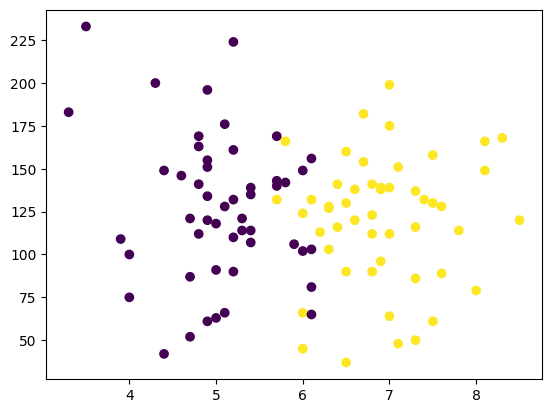

In [39]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement']) # placement wala color coded

In [42]:
# Extract i/p and o/p columns
X = df.iloc[:,0:2] # independent variables
y = df.iloc[:,-1] # dependent variable

In [43]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [46]:
# Train test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1) # training data mei kitna nad test mei kitna , yaha 10% test mei jayega

In [47]:
X_train

,cgpa,iq
32,7.0,139.0
3,7.4,132.0
55,7.8,114.0
45,6.0,66.0
56,6.1,65.0
...,...,...
19,5.2,132.0
46,5.3,114.0
4,5.8,142.0
73,4.9,61.0


In [49]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [53]:
X_train = scaler.fit_transform(X_train) # pehle smjhega then transform kardega [-1 to 1]

In [54]:
X_train

array([[ 0.90931389,  0.41738416],
       [ 1.26590757,  0.2449566 ],
       [ 1.62250126, -0.19842853],
       [ 0.01782968, -1.3807889 ],
       [ 0.1069781 , -1.40542141],
       [ 1.17675915, -0.88813875],
       [ 1.88994652,  0.66370923],
       [ 1.88994652,  1.08246187],
       [ 2.2465402 , -0.05063349],
       [ 0.1069781 ,  0.83613679],
       [-0.24961558,  0.51591419],
       [ 0.73101705, -0.78960872],
       [-0.51706084, -0.37085609],
       [ 0.01782968,  0.04789654],
       [ 0.90931389,  1.30415443],
       [ 0.37442337, -0.14916352],
       [ 0.1069781 , -1.01130129],
       [-0.24961558,  0.44201667],
       [ 0.46357179,  0.19569159],
       [-0.96280294,  0.81150428],
       [-0.87365452, -0.76497621],
       [ 0.46357179, -0.78960872],
       [-0.7845061 ,  1.32878694],
       [-0.24961558,  0.2449566 ],
       [-1.14109979, -0.86350624],
       [ 0.01782968, -1.89807156],
       [ 0.28527495, -0.46938612],
       [-1.49769347,  1.91996713],
       [ 0.99846231,

In [55]:
X_test = scaler.transform(X_test)

In [56]:
X_test

array([[  6.5, 160. ],
       [  6.9,  96. ],
       [  4.8, 163. ],
       [  7.6,  89. ],
       [  4.8, 141. ],
       [  6.9, 138. ],
       [  6.9, 139. ],
       [  3.3, 183. ],
       [  6.4, 141. ],
       [  6.8, 123. ]])

In [57]:
# Train Dataset (Logistic Regression)
from sklearn.linear_model import LogisticRegression

In [59]:
clf = LogisticRegression()

In [71]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [72]:
#Evaluate the model
y_pred = clf.predict(X_test) #predicted result
y_pred

array([1, 1, 0, 1, 0, 1, 1, 0, 1, 1])

In [73]:
y_test # unn students ka actual result

,placement
38,1
66,1
34,0
42,1
51,0
11,1
60,1
17,0
54,1
0,1


In [74]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

In [75]:
from mlxtend.plotting import plot_decision_regions # plot decision boundary

<Axes: >

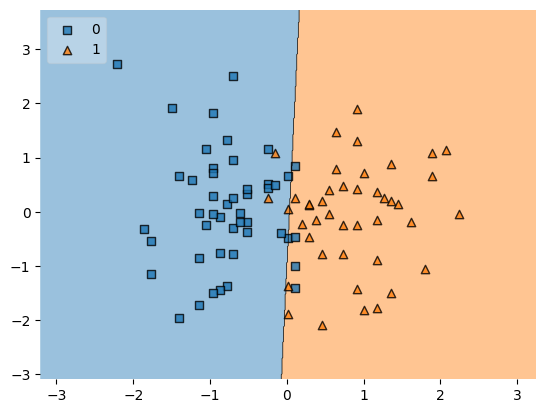

In [77]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [88]:
import pickle
# Pickle kisi bhi object ko file mei convert kardega and fir yeh file kisi aur env mei le ja skte

In [89]:
pickle.dump(clf,open('/content/model.pkl','wb'))
# yeh file aa gayi ab isme ek predict naam se function hai jisse mai apni website mei integrate kar sakta